# Практична робота №2

## **Мацишин Михайло**   **ОІ-31**

# **Варіант 3**

## Опис Компанії-Замовника:
Best Friends Animal Society: Організація в США, відома своїми зусиллями у просуванні усиновлення домашніх тварин і зниженні кількості тварин, що евтаназуються в притулках.

## Запит:
Організація шукає розв'язок для прогнозування ймовірності усиновлення тварин, що знаходяться в притулку, з метою підвищення їхніх шансів на знаходження нового дому.

## Пропозиція Реалізації:
Розробка моделі машинного навчання, для передбачення ймовірності усиновлення тварин з притулку. Модель повинна аналізувати різноманітні характеристики тварин, такі як вік, порода, здоров'я, поведінка, та інші значимі фактори, що можуть впливати на шанси тварини бути усиновленою. Цей аналіз допоможе притулку краще розуміти потреби тварин та ефективніше підходити до процесу усиновлення, збільшуючи шанси кожної тварини знайти новий дім.

# **Завдання:**

### 1) Підготовка даних вашого підприємства до подальшого моделювання використовуючи python/jupyter:

- **Замініть відсутні значення**, якщо такі присутні та обґрунтуйте вибір методу(ib)
- **Проведіть кодування (Categorical Encoding) категоріальних ознак**
- **Опрацюйте аномальні значення**
- **Використайте підхід масштабування ознак** якщо це доцільно для ваших даних

### 2) Звіт про очищення даних

### 3) Обґрунтування методів інженерії даних, які були використані для підготовки даних вашого підприємства.

## Імпорт бібліотек

In [3]:
import os.path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import warnings
warnings.simplefilter('ignore')

## Читання набору даних

In [5]:
os.path.exists("variant_3.csv")

True

In [52]:
ds = pd.read_csv("variant_3.csv")

In [7]:
print('columns count - ',len(ds.columns), '\n')
print('columns: ',list(ds.columns))

columns count -  26 

columns:  ['Unnamed: 0', 'Type', 'Name', 'Age', 'Gender', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'Quantity', 'Fee', 'State', 'RescuerID', 'VideoAmt', 'Description', 'PetID', 'PhotoAmt', 'AdoptionSpeed', 'ColorName_x', 'ColorName_y', 'ColorName', 'BreedName_x', 'BreedName_y', 'StateName_x']


## Врахування відсутніх даних

In [8]:
ds.shape

(1356, 26)

In [9]:
missing = []

for x in ds.columns:
    if ds[x].isnull().sum() != 0:
        print(x, ds[x].isnull().sum())
        missing.append(x)

Name 112
Gender 67
MaturitySize 135
ColorName 207
BreedName_x 148
BreedName_y 135


In [10]:
def impute_na(df, variable, value):

    return df[variable].fillna(value)

In [12]:
ds.nunique()

Unnamed: 0       1356
Type                2
Name             1147
Age                51
Gender              3
MaturitySize        4
FurLength           3
Vaccinated          3
Dewormed            3
Sterilized          3
Health              3
Quantity           13
Fee                28
State              12
RescuerID         819
VideoAmt            8
Description      1323
PetID            1356
PhotoAmt           30
AdoptionSpeed       5
ColorName_x         5
ColorName_y         5
ColorName           5
BreedName_x        94
BreedName_y        86
StateName_x        12
dtype: int64

ds.describe()

### Рядки з великою кількістю пропущених значень: 

In [149]:
total_columns = ds.shape[1]
rows_missing_data = ds.isnull().sum(axis=1)
rows_with_many_missing = rows_missing_data[rows_missing_data > total_columns * 0.5]
rows_with_many_missing

Series([], dtype: int64)

Не було знайдено жодного рядка, де пропущені значення перевищували б 50% всіх колонок. Отже, не існує рядків, що містять переважно пропущені дані і варто було б видалити за цим критерієм.

## Заміна відсутніх значень

#### **Заміна відсутніх даних довільним (Arbitrary value) значенням для категоріальних змінних**

Поле "Name" є категоріальною змінною, що містить імена домашніх тварин. Пропущені значення у цьому полі можуть вказувати на те, що тварині не було присвоєно ім'я або ім'я не було занесено до бази з певних причин. Використання методу заміни на довільне значення "Unknown" є доцільним, оскільки:
- **Збереження інформації про відсутність імені**: введення категорії "Unknown" дозволяє зберігати інформацію про те, що ім'я тварині не було відоме або не було присвоєно.
- **Запобігання втраті даних**: замість видалення рядків з пропущеними даними, цей метод дозволяє зберегти всі записи, що підвищує якість аналізу даних.
- **Вплив на аналіз**: присутність або відсутність імені може не мати значного впливу на аналіз, тому така заміна є безпечною та ефективною.

In [23]:
# Виведення рядка з пропущеними значеннями в стовпці 'Name'
from IPython.display import display

display_row = ds.loc[[27]]
display(display_row)

,Unnamed: 0,Type,Name,Age,Gender,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,...,Description,PetID,PhotoAmt,AdoptionSpeed,ColorName_x,ColorName_y,ColorName,BreedName_x,BreedName_y,StateName_x
27,27,1,NaN,2,NaN,2.0,1,2,1,2,...,Very Cute.....Very Healthy........taught and k...,22a0baf52,3.0,4,Brown,Yellow,NaN,Mixed Breed,Mixed Breed,Selangor


In [178]:
ds['Name'].isnull().mean()

ds['Name'].isna().mean() * 100

8.259587020648967

In [26]:
ds['Name'].fillna('Unknown', inplace=True)

In [27]:
display_row = ds.loc[[27]]
display(display_row)

,Unnamed: 0,Type,Name,Age,Gender,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,...,Description,PetID,PhotoAmt,AdoptionSpeed,ColorName_x,ColorName_y,ColorName,BreedName_x,BreedName_y,StateName_x
27,27,1,Unknown,2,NaN,2.0,1,2,1,2,...,Very Cute.....Very Healthy........taught and k...,22a0baf52,3.0,4,Brown,Yellow,NaN,Mixed Breed,Mixed Breed,Selangor


### Видалення стовпця Unnamed 0

In [65]:
# Видалення стовпця 'Unnamed: 0'
ds.drop('Unnamed: 0', axis=1, inplace=True)

In [66]:
display_row = ds.loc[[27]]
display(display_row)

,Type,Name,Age,Gender,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,...,PetID,PhotoAmt,AdoptionSpeed,ColorName_x,ColorName_y,ColorName,BreedName_x,BreedName_y,StateName_x,MaturitySize_ModeImputed
27,1,NaN,2,NaN,2.0,1,2,1,2,1,...,22a0baf52,3.0,4,Brown,Yellow,NaN,Mixed Breed,Mixed Breed,Selangor,2.0


### Аналіз "MaturitySize"
Передбачуваний розмір дорослої тварини

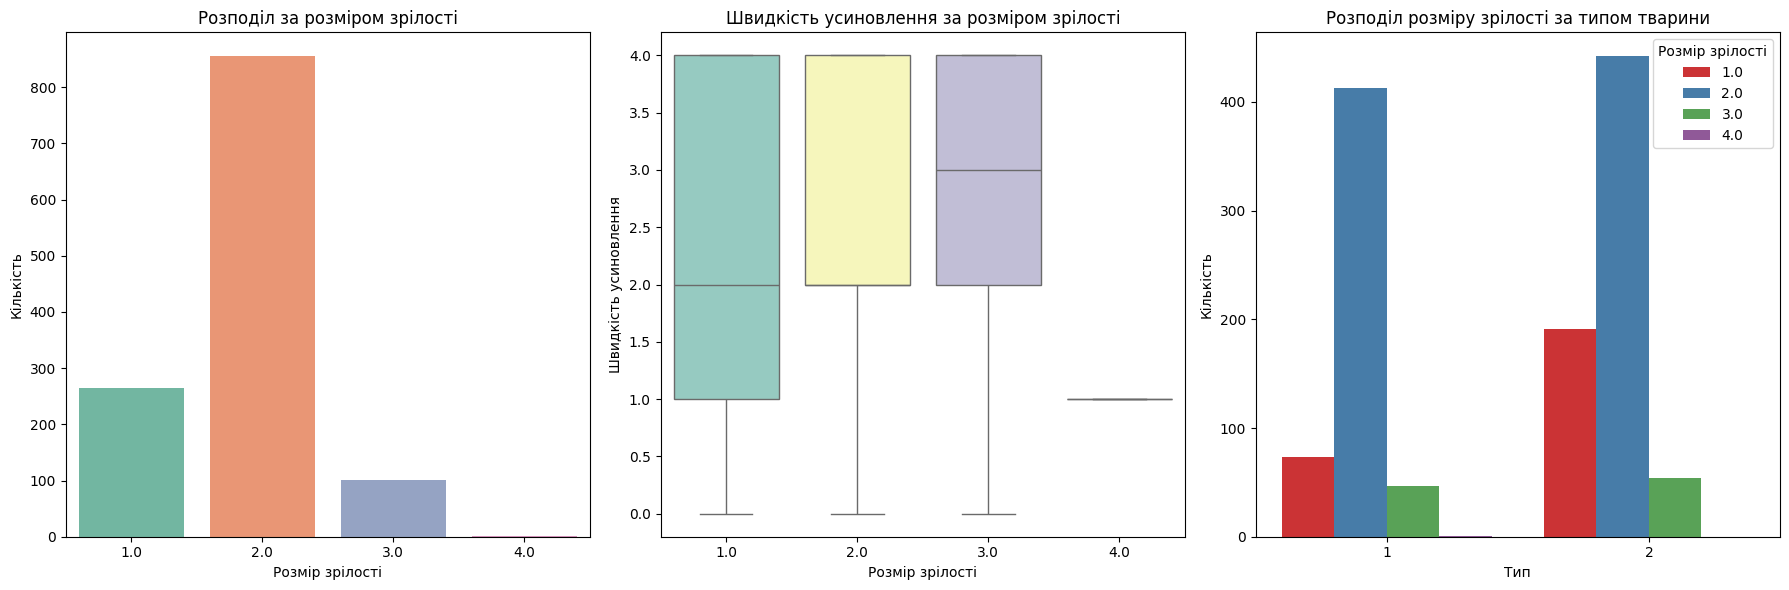

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Графік розподілу 'MaturitySize'
sns.countplot(x='MaturitySize', data=ds, ax=axes[0], palette='Set2')
axes[0].set_title('Розподіл за розміром зрілості')
axes[0].set_xlabel('Розмір зрілості')
axes[0].set_ylabel('Кількість')

# Відносини між 'MaturitySize' та 'AdoptionSpeed'
sns.boxplot(x='MaturitySize', y='AdoptionSpeed', data=ds, ax=axes[1], palette='Set3')
axes[1].set_title('Швидкість усиновлення за розміром зрілості')
axes[1].set_xlabel('Розмір зрілості')
axes[1].set_ylabel('Швидкість усиновлення')

# Зв'язок 'MaturitySize' з типом тварини (1 = Собака, 2 = Кішка)
sns.countplot(x='Type', hue='MaturitySize', data=ds, ax=axes[2], palette='Set1')
axes[2].set_title('Розподіл розміру зрілості за типом тварини')
axes[2].set_xlabel('Тип')
axes[2].set_ylabel('Кількість')
axes[2].legend(title='Розмір зрілості')

plt.tight_layout()
plt.show()

**Розподіл MaturitySize**

Більшість тварин у датасеті мають середній розмір дорослої особи (MaturitySize 2.0), за ними йдуть тварини малого розміру (1.0), далі великі (3.0) і дуже великі (4.0) у значно меншій кількості (лише 1).

**AdoptionSpeed за MaturitySize**

Відношення швидкості усиновлення до розміру зрілості показує, що малі тварини (1.0) мають трохи нижчу медіану швидкості усиновлення порівняно з іншими категоріями, що може свідчити про популярність менших тварин або їх швидше усиновлення. Великі та дуже великі тварини (3.0, 4.0) мають вищу медіану, що може вказувати на більш тривалий час усиновлення.

**MaturitySize за Type**

Собаки мають більш високу частку тварин середнього та великого розміру, тоді як кішки частіше мають малий розмір.


*У наборі даних є три категорії гендеру: самці, самки, та групи тварин. Оскільки коти зазвичай менші за розміром порівняно з собаками, розгляд умовної імпутації, де враховуються тип тварини (собака або кіт), може здатися логічним для заповнення пропущених значень у стовпці MaturitySize. Однак, MaturitySize є порядковою змінною, що означає, що ми не можемо використовувати середнє значення для імпутації, оскільки це може призвести до нереалістичних результатів.*

*Після аналізу розподілу MaturitySize за типом тварини видно, що розподіл розмірів є досить схожим між собаками та котами, що знижує необхідність застосування складнішої умовної імпутації за типом тварини. Таким чином, мода або медіана загального розподілу можуть ефективно заповнити пропущені значення, не розділяючи тварин за типом або гендером.*

*На основі аналізу, я вирішив використовувати імпутацію модою для всіх пропущених значень у MaturitySize, оскільки це значення відображає найчастіше спостережуваний розмір тварин у наборі даних. Це допомагає зберегти природний розподіл розмірів без додавання складності умовної імпутації.*

In [43]:
# Обчислення відсотка відсутніх значень для стовпця "MaturitySize".
missing_percentage = ds['MaturitySize'].isna().mean() * 100
missing_percentage

9.955752212389381

#### **Заміна відсутніх значень на  категорію, що найчастіше зустрічається (Mode imputation)**

In [69]:
mode_value = ds['MaturitySize'].mode()[0]
ds['MaturitySize_ModeImputed'] = ds['MaturitySize'].fillna(mode_value)

ds.head(14)

,Type,Name,Age,Gender,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,...,PetID,PhotoAmt,AdoptionSpeed,ColorName_x,ColorName_y,ColorName,BreedName_x,BreedName_y,StateName_x,MaturitySize_ModeImputed
0,2,Golden Tabby Girl,1,2.0,NaN,1,2,1,2,1,...,dae13a47e,7.0,1,Brown,Golden,NaN,Tabby,Domestic Short Hair,Selangor,2.0
1,2,Ogen & Oyen,2,3.0,1.0,2,2,2,2,1,...,718b14a08,2.0,1,Brown,Golden,Cream,Domestic Medium Hair,Domestic Short Hair,Selangor,1.0
2,2,Noah And Nellie,2,3.0,1.0,1,1,1,2,1,...,4a590a1cc,5.0,1,Brown,Golden,Cream,Tabby,Tabby,Selangor,1.0
3,2,Money,1,2.0,1.0,1,3,3,3,1,...,19982272a,4.0,4,Brown,Golden,Cream,Domestic Short Hair,Domestic Medium Hair,Selangor,1.0
4,1,Karlo,2,1.0,2.0,2,2,2,2,1,...,f61c4cead,1.0,3,Brown,Golden,Cream,Mixed Breed,Mixed Breed,Selangor,2.0
5,1,Puppy,2,1.0,1.0,1,2,2,3,1,...,8cf927527,1.0,3,Brown,Golden,Cream,Mixed Breed,Mixed Breed,Selangor,1.0
6,1,Lola,2,2.0,2.0,1,3,1,1,1,...,030f32f08,3.0,4,Brown,Golden,Cream,Mixed Breed,Mixed Breed,Selangor,2.0
7,1,Peanut,2,2.0,2.0,1,3,3,3,1,...,8019d0c63,3.0,4,Brown,Golden,Cream,Mixed Breed,Mixed Breed,Selangor,2.0
8,1,Honey,12,2.0,2.0,2,2,2,2,1,...,f5fc7d4a5,1.0,4,Brown,Golden,Cream,Terrier,Mixed Breed,Selangor,2.0
9,1,Naari,36,2.0,2.0,3,1,1,1,1,...,1a54d4e92,3.0,3,Brown,Golden,Cream,Terrier,Terrier,Selangor,2.0


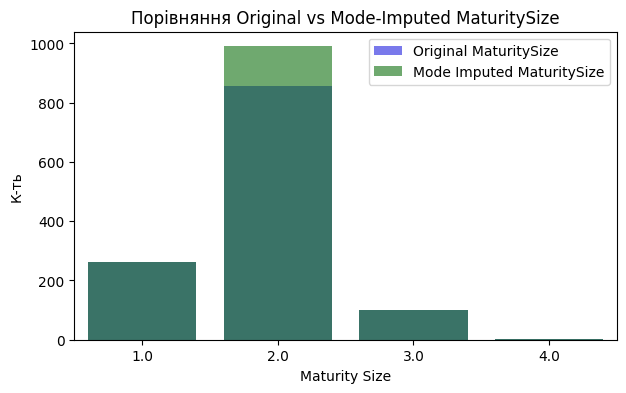

In [76]:
plt.figure(figsize=(7, 4))

sns.countplot(x='MaturitySize', data=ds, color='blue', alpha=0.6, label='Original MaturitySize')

sns.countplot(x='MaturitySize_ModeImputed', data=ds, color='green', alpha=0.6, label='Mode Imputed MaturitySize')
plt.title('Порівняння Original vs Mode-Imputed MaturitySize')
plt.xlabel('Maturity Size')
plt.ylabel('К-ть')
plt.legend()
plt.show()

In [84]:
print('Original variable variance: ', ds['MaturitySize'].var())
print('Variance after imputation: ', ds['MaturitySize_ModeImputed'].var())

Original variable variance:  0.2850579342382621
Variance after imputation:  0.2582171352686979


**Аналіз методу:**

*Перевага:* цей метод простий і дозволяє швидко заповнити пропущені значення без великих зусиль. Розподіл даних стає повним, і можна переходити до подальшого аналізу чи моделювання.

*Недолік:* зважаючи на те, що відсоток пропущених даних перевищує 5%, ми бачимо можливий дисбаланс у розподілі категорій після імпутації. Це може вказувати на те, що імпутація модою **не ідеально підходить для цієї змінної** і може спотворити результати моделі через надмірне представлення одного розміру.

#### **Заміна відсутніх даних випадковими значеннями**

In [79]:
def random_impute(column):
    non_null_values = column.dropna()
    return column.apply(lambda x: np.random.choice(non_null_values) if pd.isna(x) else x)

ds['MaturitySize_RandomImputed'] = random_impute(ds['MaturitySize'])

ds.head(14)

,Type,Name,Age,Gender,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,...,PhotoAmt,AdoptionSpeed,ColorName_x,ColorName_y,ColorName,BreedName_x,BreedName_y,StateName_x,MaturitySize_ModeImputed,MaturitySize_RandomImputed
0,2,Golden Tabby Girl,1,2.0,NaN,1,2,1,2,1,...,7.0,1,Brown,Golden,NaN,Tabby,Domestic Short Hair,Selangor,2.0,2.0
1,2,Ogen & Oyen,2,3.0,1.0,2,2,2,2,1,...,2.0,1,Brown,Golden,Cream,Domestic Medium Hair,Domestic Short Hair,Selangor,1.0,1.0
2,2,Noah And Nellie,2,3.0,1.0,1,1,1,2,1,...,5.0,1,Brown,Golden,Cream,Tabby,Tabby,Selangor,1.0,1.0
3,2,Money,1,2.0,1.0,1,3,3,3,1,...,4.0,4,Brown,Golden,Cream,Domestic Short Hair,Domestic Medium Hair,Selangor,1.0,1.0
4,1,Karlo,2,1.0,2.0,2,2,2,2,1,...,1.0,3,Brown,Golden,Cream,Mixed Breed,Mixed Breed,Selangor,2.0,2.0
5,1,Puppy,2,1.0,1.0,1,2,2,3,1,...,1.0,3,Brown,Golden,Cream,Mixed Breed,Mixed Breed,Selangor,1.0,1.0
6,1,Lola,2,2.0,2.0,1,3,1,1,1,...,3.0,4,Brown,Golden,Cream,Mixed Breed,Mixed Breed,Selangor,2.0,2.0
7,1,Peanut,2,2.0,2.0,1,3,3,3,1,...,3.0,4,Brown,Golden,Cream,Mixed Breed,Mixed Breed,Selangor,2.0,2.0
8,1,Honey,12,2.0,2.0,2,2,2,2,1,...,1.0,4,Brown,Golden,Cream,Terrier,Mixed Breed,Selangor,2.0,2.0
9,1,Naari,36,2.0,2.0,3,1,1,1,1,...,3.0,3,Brown,Golden,Cream,Terrier,Terrier,Selangor,2.0,2.0


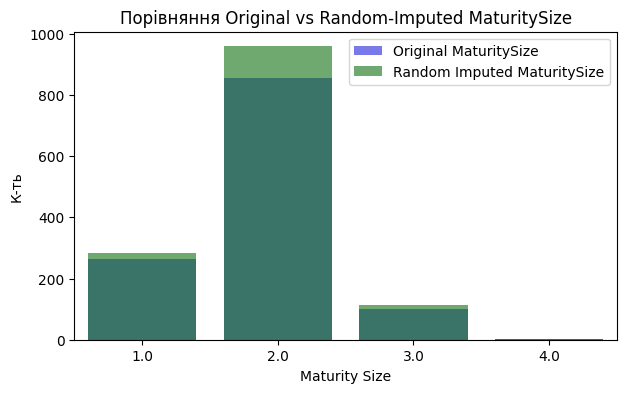

In [82]:
plt.figure(figsize=(7, 4))
sns.countplot(x='MaturitySize', data=ds, color='blue', alpha=0.6, label='Original MaturitySize')
sns.countplot(x='MaturitySize_RandomImputed', data=ds, color='green', alpha=0.6, label='Random Imputed MaturitySize')
plt.title('Порівняння Original vs Random-Imputed MaturitySize')
plt.xlabel('Maturity Size')
plt.ylabel('К-ть')
plt.legend()
plt.show()

In [83]:
print('Original variable variance: ', ds['MaturitySize'].var())
print('Variance after imputation: ', ds['MaturitySize_RandomImputed'].var())

Original variable variance:  0.2850579342382621
Variance after imputation:  0.27947403367838985


**Аналіз методу:**

*Перевага:* 

- Зберігає дисперсію та розподіл змінної, оскільки випадкові вибірки відображають наявний розподіл у даних.
- Простий у реалізації і підходить для категоріальних та числових змінних.

*Недолік:*

- Якщо пропущених даних багато, цей метод може спотворити взаємозв'язки змінної з іншими змінними через випадковість. Він також може бути складнішим у розгортанні на нові дані, оскільки для правильного відбору потрібно зберігати вихідний набір даних.

Метод заміни відсутніх даних випадковими значеннями **є доречним у нашому випадку**, навіть якщо відсоток пропущених значень у змінній MaturitySize перевищує 5% (9.96%). Основна перевага цього методу полягає в тому, що він зберігає розподіл та дисперсію змінної, оскільки пропущені значення заповнюються випадковими спостереженнями з наявних даних. Завдяки цьому підходу ми уникаємо надмірного представлення однієї категорії, що могло б статися при імпутації модою, і підтримуємо різноманітність даних.

### Аналіз "Gender"

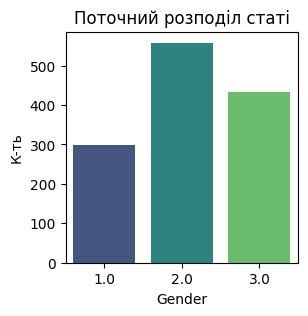

In [93]:
plt.figure(figsize=(3, 3))
sns.countplot(x='Gender', data=ds, palette='viridis')
plt.title('Поточний розподіл статі')
plt.xlabel('Gender')
plt.ylabel('К-ть')
plt.show()

In [88]:
# Обчислення відсотка відсутніх значень для стовпця "Gender".
missing_percentage = ds['Gender'].isna().mean() * 100
missing_percentage

4.941002949852508

#### **Заміна відсутніх даних випадковими значеннями**

- Імпутація випадковими значеннями зберігає розподіл категоріальної змінної, що є важливим для мінімізації впливу на результати моделювання.

- Використання моди в нашому випадку може призвести до збільшення частки категорії "2.0" (самка), що створить дисбаланс у даних.

- Імпутація випадковими значеннями забезпечить, що кожна категорія отримає кількість заповнених пропущених значень, пропорційно до свого початкового розподілу, що підтримує варіативність у даних.

In [152]:
def random_impute(column):
    non_null_values = column.dropna()
    return column.apply(lambda x: np.random.choice(non_null_values) if pd.isna(x) else x)

ds['Gender_RandomImputed'] = random_impute(ds['Gender'])

ds.head(34)

,Type,Name,Age,Gender,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,ColorName_x,ColorName_y,ColorName,BreedName_x,BreedName_y,StateName_x,MaturitySize_ModeImputed,MaturitySize_RandomImputed,Gender_RandomImputed,ColorName_Filled
0,2,Golden Tabby Girl,1,2.0,NaN,1,2,1,2,1,1,50,41326,438a9bdce8ef4d5948fc40e422d34d0d,0,A cute tabby kitten looking for new home. She ...,dae13a47e,7.0,1,Brown,Golden,NaN,Tabby,Domestic Short Hair,Selangor,2.0,2.0,2.0,Cream
1,2,Ogen & Oyen,2,3.0,1.0,2,2,2,2,1,2,0,41326,15316b9044ea4f6a57f6cb4b45fc67aa,0,Ogen (male) & Oyen (female) are about 2 months...,718b14a08,2.0,1,Brown,Golden,Cream,Domestic Medium Hair,Domestic Short Hair,Selangor,1.0,1.0,3.0,Cream
2,2,Noah And Nellie,2,3.0,1.0,1,1,1,2,1,2,0,41326,2e4363f80f02bda5f2f8115b6ce6aef6,0,"Once again, thanks to petfinder, Noah and Nell...",4a590a1cc,5.0,1,Brown,Golden,Cream,Tabby,Tabby,Selangor,1.0,1.0,3.0,Cream
3,2,Money,1,2.0,1.0,1,3,3,3,1,1,0,41326,5201c3e05aa6ff174b006c070e9a06b5,0,Please adopt this cute little kitten... I eant...,19982272a,4.0,4,Brown,Golden,Cream,Domestic Short Hair,Domestic Medium Hair,Selangor,1.0,1.0,2.0,Cream
4,1,Karlo,2,1.0,2.0,2,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,"Meet Karlo, brother of little Karla, the cutes...",f61c4cead,1.0,3,Brown,Golden,Cream,Mixed Breed,Mixed Breed,Selangor,2.0,2.0,1.0,Cream
5,1,Puppy,2,1.0,1.0,1,2,2,3,1,3,0,41326,793a857b0f2db4c0ed8fd9e38cc7cb5f,0,Those puppies at damansara. all puppis are mal...,8cf927527,1.0,3,Brown,Golden,Cream,Mixed Breed,Mixed Breed,Selangor,1.0,1.0,1.0,Cream
6,1,Lola,2,2.0,2.0,1,3,1,1,1,1,0,41326,e8b60179614aa81703e01108649313b4,0,"""Lola"" Friendly, petite sized dog available fo...",030f32f08,3.0,4,Brown,Golden,Cream,Mixed Breed,Mixed Breed,Selangor,2.0,2.0,2.0,Cream
7,1,Peanut,2,2.0,2.0,1,3,3,3,1,1,0,41326,935ec4de4f15f6f68fef5d9ae678ea18,0,Friendly and bubbly little pup . Seems pretty ...,8019d0c63,3.0,4,Brown,Golden,Cream,Mixed Breed,Mixed Breed,Selangor,2.0,2.0,2.0,Cream
8,1,Honey,12,2.0,2.0,2,2,2,2,1,1,0,41326,ef52d7a48aa67cf013b1d54a7ac7d806,0,Original owner had a few puppies and was not a...,f5fc7d4a5,1.0,4,Brown,Golden,Cream,Terrier,Mixed Breed,Selangor,2.0,2.0,2.0,Cream
9,1,Naari,36,2.0,2.0,3,1,1,1,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,Naari is the sweetest girl who walked the eart...,1a54d4e92,3.0,3,Brown,Golden,Cream,Terrier,Terrier,Selangor,2.0,2.0,2.0,Cream


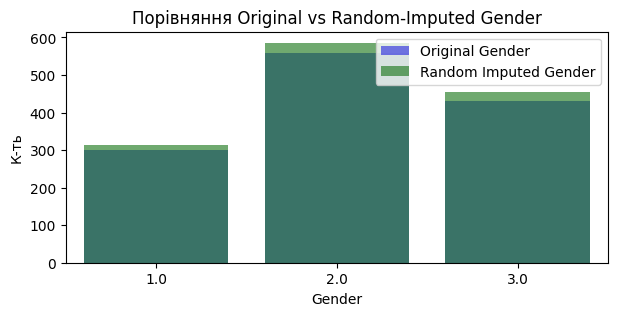

In [99]:
plt.figure(figsize=(7, 3))
sns.countplot(x='Gender', data=ds, color='blue', alpha=0.6, label='Original Gender')
sns.countplot(x='Gender_RandomImputed', data=ds, color='green', alpha=0.6, label='Random Imputed Gender')
plt.title('Порівняння Original vs Random-Imputed Gender')
plt.xlabel('Gender')
plt.ylabel('К-ть')
plt.legend()
plt.show()

In [100]:
print('Original variable variance: ', ds['Gender'].var())
print('Variance after imputation: ', ds['Gender_RandomImputed'].var())

Original variable variance:  0.5568920488220923
Variance after imputation:  0.5572913605242248


**Висновки:**

*Збереження розподілу:* 

- Метод імпутації випадковими значеннями дозволив зберегти первісний розподіл значень по гендерам, що є критично важливим для подальшої аналітики і моделювання.

*Мінімальні зміни дисперсії:*

- Збереження схожості дисперсій перед і після імпутації підтверджує, що метод не вніс значних спотворень у статистичні характеристики змінної.

Цей аналіз підтверджує, що вибраний метод імпутації ефективно вирішує проблему пропущених значень для змінної Gender, зберігаючи при цьому основні статистичні характеристики даних.

### Аналіз "ColorName"

#### **Метод заповнення пропущених значень найближчим сусідом (Forward Fill/Backward Fill)**

Цей метод вибрано через його ефективність у збереженні первісних закономірностей даних в умовах, коли пропущені значення виникають у послідовностях, які мають внутрішній зв'язок. Forward Fill та Backward Fill дозволяють зберігати контекстуальну цілісність, заповнюючи пропущені значення відповідно попередніми або наступними

- *Forward Fill (заповнення пропущених значень попередніми значеннями)* використовується для випадків, коли важливо зберегти інформацію, яка передує пропуску, забезпечуючи логічну послідовність значень.
- *Backward Fill (заповнення пропущених значень наступними значеннями)* застосовується для заповнення пропусків, коли після них одразу слідують важливі дані, дозволяючи зберігти логіку послідовності значень.

In [114]:
# Forward Fill (заповнюємо пропущені значення попередніми значеннями)
ds['ColorName_Filled'] = ds['ColorName'].fillna(method='ffill')

# Backward Fill (заповнюємо решту пропущених значень наступними значеннями)
ds['ColorName_Filled'] = ds['ColorName_Filled'].fillna(method='bfill')

In [192]:
print(ds[['ColorName_x', 'ColorName_y', 'ColorName', 'ColorName_Filled']].head(50))

   ColorName_x ColorName_y ColorName ColorName_Filled
0        Brown      Golden       NaN            Cream
1        Brown      Golden     Cream            Cream
2        Brown      Golden     Cream            Cream
3        Brown      Golden     Cream            Cream
4        Brown      Golden     Cream            Cream
5        Brown      Golden     Cream            Cream
6        Brown      Golden     Cream            Cream
7        Brown      Golden     Cream            Cream
8        Brown      Golden     Cream            Cream
9        Brown      Golden     Cream            Cream
10       Brown      Golden     Cream            Cream
11       Black      Golden     Cream            Cream
12       Black      Golden       NaN            Cream
13       Black      Golden     Cream            Cream
14       Black      Golden     Cream            Cream
15       Black      Golden     Cream            Cream
16       Black      Golden     Cream            Cream
17       Black      Golden  

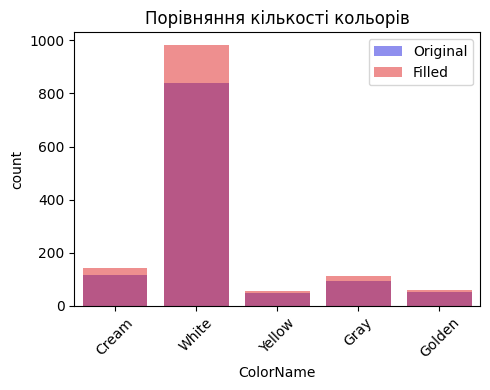

In [144]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.countplot(x='ColorName', data=ds, color='blue', alpha=0.5, label='Original')
sns.countplot(x='ColorName_Filled', data=ds, color='red', alpha=0.5, label='Filled')

ax.set_title('Порівняння кількості кольорів')
ax.tick_params(axis='x', rotation=45)

plt.legend()

plt.tight_layout()
plt.show()

### Аналіз "BreedName_x та BreedName_y"

#### **Заміна відсутніх даних довільним (Arbitrary value) значенням для категоріальних змінних**

In [162]:
ds['BreedName_x'].fillna('Unknown', inplace=True)
ds['BreedName_y'].fillna('Unknown', inplace=True)

In [167]:
ds.head(10)

,Type,Name,Age,Gender,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,ColorName_x,ColorName_y,ColorName,BreedName_x,BreedName_y,StateName_x,MaturitySize_ModeImputed,MaturitySize_RandomImputed,Gender_RandomImputed,ColorName_Filled
0,2,Golden Tabby Girl,1,2.0,NaN,1,2,1,2,1,1,50,41326,438a9bdce8ef4d5948fc40e422d34d0d,0,A cute tabby kitten looking for new home. She ...,dae13a47e,7.0,1,Brown,Golden,NaN,Tabby,Domestic Short Hair,Selangor,2.0,2.0,2.0,Cream
1,2,Ogen & Oyen,2,3.0,1.0,2,2,2,2,1,2,0,41326,15316b9044ea4f6a57f6cb4b45fc67aa,0,Ogen (male) & Oyen (female) are about 2 months...,718b14a08,2.0,1,Brown,Golden,Cream,Domestic Medium Hair,Domestic Short Hair,Selangor,1.0,1.0,3.0,Cream
2,2,Noah And Nellie,2,3.0,1.0,1,1,1,2,1,2,0,41326,2e4363f80f02bda5f2f8115b6ce6aef6,0,"Once again, thanks to petfinder, Noah and Nell...",4a590a1cc,5.0,1,Brown,Golden,Cream,Tabby,Tabby,Selangor,1.0,1.0,3.0,Cream
3,2,Money,1,2.0,1.0,1,3,3,3,1,1,0,41326,5201c3e05aa6ff174b006c070e9a06b5,0,Please adopt this cute little kitten... I eant...,19982272a,4.0,4,Brown,Golden,Cream,Domestic Short Hair,Domestic Medium Hair,Selangor,1.0,1.0,2.0,Cream
4,1,Karlo,2,1.0,2.0,2,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,"Meet Karlo, brother of little Karla, the cutes...",f61c4cead,1.0,3,Brown,Golden,Cream,Mixed Breed,Mixed Breed,Selangor,2.0,2.0,1.0,Cream
5,1,Puppy,2,1.0,1.0,1,2,2,3,1,3,0,41326,793a857b0f2db4c0ed8fd9e38cc7cb5f,0,Those puppies at damansara. all puppis are mal...,8cf927527,1.0,3,Brown,Golden,Cream,Mixed Breed,Mixed Breed,Selangor,1.0,1.0,1.0,Cream
6,1,Lola,2,2.0,2.0,1,3,1,1,1,1,0,41326,e8b60179614aa81703e01108649313b4,0,"""Lola"" Friendly, petite sized dog available fo...",030f32f08,3.0,4,Brown,Golden,Cream,Mixed Breed,Mixed Breed,Selangor,2.0,2.0,2.0,Cream
7,1,Peanut,2,2.0,2.0,1,3,3,3,1,1,0,41326,935ec4de4f15f6f68fef5d9ae678ea18,0,Friendly and bubbly little pup . Seems pretty ...,8019d0c63,3.0,4,Brown,Golden,Cream,Mixed Breed,Mixed Breed,Selangor,2.0,2.0,2.0,Cream
8,1,Honey,12,2.0,2.0,2,2,2,2,1,1,0,41326,ef52d7a48aa67cf013b1d54a7ac7d806,0,Original owner had a few puppies and was not a...,f5fc7d4a5,1.0,4,Brown,Golden,Cream,Terrier,Mixed Breed,Selangor,2.0,2.0,2.0,Cream
9,1,Naari,36,2.0,2.0,3,1,1,1,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,Naari is the sweetest girl who walked the eart...,1a54d4e92,3.0,3,Brown,Golden,Cream,Terrier,Terrier,Selangor,2.0,2.0,2.0,Cream


### Додавання змінної для виявлення NA

In [198]:
def missing_indicator(df, variable):
    return np.where(df[variable].isnull(), 1, 0)

ds['Gender_NA'] = missing_indicator(ds, 'Gender')
ds['MaturitySize_NA'] = missing_indicator(ds, 'MaturitySize')
ds['ColorName_NA'] = missing_indicator(ds, 'ColorName')

print(ds[['Gender', 'Gender_NA', 'MaturitySize', 'MaturitySize_NA', 'ColorName', 'ColorName_NA']].head(55))

    Gender  Gender_NA  MaturitySize  MaturitySize_NA ColorName  ColorName_NA
0      2.0          0           NaN                1       NaN             1
1      3.0          0           1.0                0     Cream             0
2      3.0          0           1.0                0     Cream             0
3      2.0          0           1.0                0     Cream             0
4      1.0          0           2.0                0     Cream             0
5      1.0          0           1.0                0     Cream             0
6      2.0          0           2.0                0     Cream             0
7      2.0          0           2.0                0     Cream             0
8      2.0          0           2.0                0     Cream             0
9      2.0          0           2.0                0     Cream             0
10     1.0          0           2.0                0     Cream             0
11     2.0          0           1.0                0     Cream             0

## Кодування (Encoding) категоріальних ознак

In [219]:
# for one hot encoding with sklearn
from sklearn.preprocessing import OneHotEncoder

In [150]:
ds.nunique()

Type                             2
Name                          1147
Age                             51
Gender                           3
MaturitySize                     4
FurLength                        3
Vaccinated                       3
Dewormed                         3
Sterilized                       3
Health                           3
Quantity                        13
Fee                             28
State                           12
RescuerID                      819
VideoAmt                         8
Description                   1323
PetID                         1356
PhotoAmt                        30
AdoptionSpeed                    5
ColorName_x                      5
ColorName_y                      5
ColorName                        5
BreedName_x                     94
BreedName_y                     86
StateName_x                     12
MaturitySize_ModeImputed         4
MaturitySize_RandomImputed       4
Gender_RandomImputed             3
ColorName_Filled    

In [199]:
ds['ColorName_x'].unique()

array(['Brown', 'Black', 'Golden', 'Yellow', 'Cream'], dtype=object)

In [200]:
ds['ColorName_y'].unique()

array(['Golden', 'Yellow', 'Brown', 'Gray', 'Cream'], dtype=object)

In [201]:
ds['ColorName_Filled'].unique()

array(['Cream', 'White', 'Yellow', 'Gray', 'Golden'], dtype=object)

In [202]:
ds['BreedName_x'].unique()

array(['Tabby', 'Domestic Medium Hair', 'Domestic Short Hair',
       'Mixed Breed', 'Terrier', 'Cocker Spaniel', 'Tortoiseshell',
       'Doberman Pinscher', 'Labrador Retriever', 'German Shepherd Dog',
       'Flat-coated Retriever', 'Dilute Tortoiseshell',
       'Domestic Long Hair', 'American Shorthair', 'Siberian Husky',
       'Unknown', 'Bengal', 'Persian', 'Siamese', 'Spitz',
       'Belgian Shepherd Malinois', 'Corgi', 'Dachshund', 'Pug',
       'Dilute Calico', 'Golden Retriever', 'Poodle', 'Abyssinian',
       'Pekingese', 'Calico', 'Japanese Bobtail', 'Beagle', 'Dalmatian',
       'German Spitz', 'Chinese Crested Dog', 'Pomeranian', 'Burmese',
       'Balinese', 'Shih Tzu', 'Silver', 'Oriental Short Hair',
       'Oriental Tabby', 'Schnauzer', 'Husky', 'Siberian', 'Russian Blue',
       'Shepherd', 'Bullmastiff', 'Ragdoll', 'Maine Coon', 'Rottweiler',
       'Jack Russell Terrier', 'Basset Hound', 'Oriental Long Hair',
       'Border Collie', 'Korat', 'Silky Terrier', 'Whi

In [203]:
ds['BreedName_y'].unique()

array(['Domestic Short Hair', 'Tabby', 'Domestic Medium Hair',
       'Mixed Breed', 'Terrier', 'Cocker Spaniel', 'Hound',
       'Golden Retriever', 'Retriever', 'Tiger', 'Tortoiseshell',
       'Labrador Retriever', 'Maine Coon', 'Spitz', 'Unknown',
       'American Shorthair', 'Domestic Long Hair', 'Miniature Pinscher',
       'German Shepherd Dog', 'Welsh Corgi', 'Exotic Shorthair',
       'Shih Tzu', 'Abyssinian', 'Persian', 'Bobtail', 'Silky Terrier',
       'Calico', 'Manx', 'Turkish Angora', 'British Shorthair',
       'Turkish Van', 'Sheep Dog', 'Siamese', 'Bengal', 'Burmese',
       'Poodle', 'Oriental Tabby', 'Oriental Short Hair', 'Tuxedo',
       'Dalmatian', 'Egyptian Mau', 'Russian Blue',
       'Yorkshire Terrier Yorkie', 'Jack Russell Terrier', 'Shar Pei',
       'Birman', 'Basset Hound', 'Border Collie', 'Pekingese',
       'Australian Terrier', 'American Curl', 'Dachshund', 'Tonkinese',
       'Bluetick Coonhound', 'Pointer', 'Doberman Pinscher', 'Rottweiler',
      

In [204]:
ds['StateName_x'].unique()

array(['Selangor', 'Kuala Lumpur', 'Pulau Pinang', 'Johor', 'Perak',
       'Terengganu', 'Kedah', 'Negeri Sembilan', 'Melaka', 'Pahang',
       'Sarawak', 'Kelantan'], dtype=object)

### Перевірка категоріальних ознак

Перед початком кодування даних використаю метод `get_dummies()` від Pandas для швидкого перегляду та аналізу розподілу категоріальних ознак. Цей метод допомагає зрозуміти, як категорії представлені у даних, і виявити можливі проблеми з незбалансованістю або відсутністю даних.


In [215]:
tmp = pd.get_dummies(ds['ColorName_x']).astype(int)

tmp.head(13)

,Black,Brown,Cream,Golden,Yellow
0,0,1,0,0,0
1,0,1,0,0,0
2,0,1,0,0,0
3,0,1,0,0,0
4,0,1,0,0,0
5,0,1,0,0,0
6,0,1,0,0,0
7,0,1,0,0,0
8,0,1,0,0,0
9,0,1,0,0,0


In [216]:
tmp = pd.get_dummies(ds['ColorName_x'], drop_first=True).astype(int)

tmp.head(13)

,Brown,Cream,Golden,Yellow
0,1,0,0,0
1,1,0,0,0
2,1,0,0,0
3,1,0,0,0
4,1,0,0,0
5,1,0,0,0
6,1,0,0,0
7,1,0,0,0
8,1,0,0,0
9,1,0,0,0


### One hot encoding з використанням Scikit-learn

*Метод One Hot Encoding для ознак 'ColorName_x', 'ColorName_y', та 'ColorName_Filled' обрав через специфіку категорій, які присутні в цих стовпцях. Кожна з цих ознак містить кілька чітко відокремлених кольорів, що є категоріальними змінними без внутрішнього порядку чи ієрархії*

In [236]:
# Створення об'єкту OneHotEncoder
encoder = OneHotEncoder(categories='auto', drop='first')

columns_to_encode = ['ColorName_x', 'ColorName_y', 'ColorName_Filled']

# Навчання енкодера
encoder.fit(ds[columns_to_encode])

OneHotEncoder(drop='first')

In [237]:
encoder.categories_

[array(['Black', 'Brown', 'Cream', 'Golden', 'Yellow'], dtype=object),
 array(['Brown', 'Cream', 'Golden', 'Gray', 'Yellow'], dtype=object),
 array(['Cream', 'Golden', 'Gray', 'White', 'Yellow'], dtype=object)]

In [246]:
encoder.get_feature_names_out()

array(['ColorName_x_Brown', 'ColorName_x_Cream', 'ColorName_x_Golden',
       'ColorName_x_Yellow', 'ColorName_y_Cream', 'ColorName_y_Golden',
       'ColorName_y_Gray', 'ColorName_y_Yellow',
       'ColorName_Filled_Golden', 'ColorName_Filled_Gray',
       'ColorName_Filled_White', 'ColorName_Filled_Yellow'], dtype=object)

In [245]:
tmp = encoder.transform(ds[['ColorName_x','ColorName_y','ColorName_Filled']])

pd.DataFrame(tmp).head()

tmp_dense = tmp.toarray()
df_encoded = pd.DataFrame(tmp_dense, columns=encoder.get_feature_names_out())
df_encoded.head(15)

,ColorName_x_Brown,ColorName_x_Cream,ColorName_x_Golden,ColorName_x_Yellow,ColorName_y_Cream,ColorName_y_Golden,ColorName_y_Gray,ColorName_y_Yellow,ColorName_Filled_Golden,ColorName_Filled_Gray,ColorName_Filled_White,ColorName_Filled_Yellow
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [249]:
# Додаємо закодовані стовпці до основної таблиці
ds = pd.concat([ds, df_encoded], axis=1)

ds.head(15)

,Type,Name,Age,Gender,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,ColorName,BreedName_x,BreedName_y,StateName_x,MaturitySize_ModeImputed,MaturitySize_RandomImputed,Gender_RandomImputed,Gender_NA,MaturitySize_NA,ColorName_NA,ColorName_x_Brown,ColorName_x_Cream,ColorName_x_Golden,ColorName_x_Yellow,ColorName_y_Cream,ColorName_y_Golden,ColorName_y_Gray,ColorName_y_Yellow,ColorName_Filled_Golden,ColorName_Filled_Gray,ColorName_Filled_White,ColorName_Filled_Yellow,ColorName_x_Brown,ColorName_x_Cream,ColorName_x_Golden,ColorName_x_Yellow,ColorName_y_Cream,ColorName_y_Golden,ColorName_y_Gray,ColorName_y_Yellow,ColorName_Filled_Golden,ColorName_Filled_Gray,ColorName_Filled_White,ColorName_Filled_Yellow,ColorName_x_Brown,ColorName_x_Cream,ColorName_x_Golden,ColorName_x_Yellow,ColorName_y_Cream,ColorName_y_Golden,ColorName_y_Gray,ColorName_y_Yellow,ColorName_Filled_Golden,ColorName_Filled_Gray,ColorName_Filled_White,ColorName_Filled_Yellow
0,2,Golden Tabby Girl,1,2.0,NaN,1,2,1,2,1,1,50,41326,438a9bdce8ef4d5948fc40e422d34d0d,0,A cute tabby kitten looking for new home. She ...,dae13a47e,7.0,1,NaN,Tabby,Domestic Short Hair,Selangor,2.0,2.0,2.0,0,1,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Ogen & Oyen,2,3.0,1.0,2,2,2,2,1,2,0,41326,15316b9044ea4f6a57f6cb4b45fc67aa,0,Ogen (male) & Oyen (female) are about 2 months...,718b14a08,2.0,1,Cream,Domestic Medium Hair,Domestic Short Hair,Selangor,1.0,1.0,3.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,Noah And Nellie,2,3.0,1.0,1,1,1,2,1,2,0,41326,2e4363f80f02bda5f2f8115b6ce6aef6,0,"Once again, thanks to petfinder, Noah and Nell...",4a590a1cc,5.0,1,Cream,Tabby,Tabby,Selangor,1.0,1.0,3.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2,Money,1,2.0,1.0,1,3,3,3,1,1,0,41326,5201c3e05aa6ff174b006c070e9a06b5,0,Please adopt this cute little kitten... I eant...,19982272a,4.0,4,Cream,Domestic Short Hair,Domestic Medium Hair,Selangor,1.0,1.0,2.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,Karlo,2,1.0,2.0,2,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,"Meet Karlo, brother of little Karla, the cutes...",f61c4cead,1.0,3,Cream,Mixed Breed,Mixed Breed,Selangor,2.0,2.0,1.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1,Puppy,2,1.0,1.0,1,2,2,3,1,3,0,41326,793a857b0f2db4c0ed8fd9e38cc7cb5f,0,Those puppies at damansara. all puppis are mal...,8cf927527,1.0,3,Cream,Mixed Breed,Mixed Breed,Selangor,1.0,1.0,1.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1,Lola,2,2.0,2.0,1,3,1,1,1,1,0,41326,e8b60179614aa81703e01108649313b4,0,"""Lola"" Friendly, petite sized dog available fo...",030f32f08,3.0,4,Cream,Mixed Breed,Mixed Breed,Selangor,2.0,2.0,2.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1,Peanut,2,2.0,2.0,1,3,3,3,1,1,0,41326,935ec4de4f15f6f68fef5d9ae678ea18,0,Friendly and bubbly little pup . Seems pretty ...,8019d0c63,3.0,4,Cream,Mixed Breed,Mixed Breed,Selangor,2.0,2.0,2.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1,Honey,12,2.0,2.0,2,2,2,2,1,1,0,41326,ef52d7a48aa67cf013b1d54a7ac7d806,0,Original owner had a few puppies and was not a...,f5fc7d4a5,1.0,4,Cream,Terrier,Mixed Bre

### Integer Encoding

*Метод обрав для колонок BreedName_x та BreedName_y, оскільки цей метод дозволяє присвоїти унікальне числове значення кожній унікальній породі, забезпечуючи консистентність між колонками та зменшуючи розмірність датасету без необхідності введення великої кількості нових змінних, як це було б при використанні One Hot Encoding*

In [257]:
# Об'єднуємо унікальні породи з обох колонок для створення унікального списку порід
unique_breeds = pd.unique(ds[['BreedName_x', 'BreedName_y']].values.ravel('K'))

unique_breeds, len(unique_breeds)

(array(['Tabby', 'Domestic Medium Hair', 'Domestic Short Hair',
        'Mixed Breed', 'Terrier', 'Cocker Spaniel', 'Tortoiseshell',
        'Doberman Pinscher', 'Labrador Retriever', 'German Shepherd Dog',
        'Flat-coated Retriever', 'Dilute Tortoiseshell',
        'Domestic Long Hair', 'American Shorthair', 'Siberian Husky',
        'Unknown', 'Bengal', 'Persian', 'Siamese', 'Spitz',
        'Belgian Shepherd Malinois', 'Corgi', 'Dachshund', 'Pug',
        'Dilute Calico', 'Golden Retriever', 'Poodle', 'Abyssinian',
        'Pekingese', 'Calico', 'Japanese Bobtail', 'Beagle', 'Dalmatian',
        'German Spitz', 'Chinese Crested Dog', 'Pomeranian', 'Burmese',
        'Balinese', 'Shih Tzu', 'Silver', 'Oriental Short Hair',
        'Oriental Tabby', 'Schnauzer', 'Husky', 'Siberian', 'Russian Blue',
        'Shepherd', 'Bullmastiff', 'Ragdoll', 'Maine Coon', 'Rottweiler',
        'Jack Russell Terrier', 'Basset Hound', 'Oriental Long Hair',
        'Border Collie', 'Korat', 'Silky

In [259]:
# Створюємо словник для мапінгу порід на числа
breed_mapping = {breed: idx for idx, breed in enumerate(unique_breeds)}

breed_mapping

{'Tabby': 0,
 'Domestic Medium Hair': 1,
 'Domestic Short Hair': 2,
 'Mixed Breed': 3,
 'Terrier': 4,
 'Cocker Spaniel': 5,
 'Tortoiseshell': 6,
 'Doberman Pinscher': 7,
 'Labrador Retriever': 8,
 'German Shepherd Dog': 9,
 'Flat-coated Retriever': 10,
 'Dilute Tortoiseshell': 11,
 'Domestic Long Hair': 12,
 'American Shorthair': 13,
 'Siberian Husky': 14,
 'Unknown': 15,
 'Bengal': 16,
 'Persian': 17,
 'Siamese': 18,
 'Spitz': 19,
 'Belgian Shepherd Malinois': 20,
 'Corgi': 21,
 'Dachshund': 22,
 'Pug': 23,
 'Dilute Calico': 24,
 'Golden Retriever': 25,
 'Poodle': 26,
 'Abyssinian': 27,
 'Pekingese': 28,
 'Calico': 29,
 'Japanese Bobtail': 30,
 'Beagle': 31,
 'Dalmatian': 32,
 'German Spitz': 33,
 'Chinese Crested Dog': 34,
 'Pomeranian': 35,
 'Burmese': 36,
 'Balinese': 37,
 'Shih Tzu': 38,
 'Silver': 39,
 'Oriental Short Hair': 40,
 'Oriental Tabby': 41,
 'Schnauzer': 42,
 'Husky': 43,
 'Siberian': 44,
 'Russian Blue': 45,
 'Shepherd': 46,
 'Bullmastiff': 47,
 'Ragdoll': 48,
 'Maine

In [262]:
# Застосувати мапінг до колонок
ds['BreedName_x'] = ds['BreedName_x'].map(breed_mapping)
ds['BreedName_y'] = ds['BreedName_y'].map(breed_mapping)

In [265]:
ds[['BreedName_x', 'BreedName_y']].head(20)

,BreedName_x,BreedName_y
0,0,2
1,1,2
2,0,0
3,2,1
4,3,3
5,3,3
6,3,3
7,3,3
8,4,3
9,4,4


In [266]:
ds.head()

,Type,Name,Age,Gender,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,ColorName,BreedName_x,BreedName_y,StateName_x,MaturitySize_ModeImputed,MaturitySize_RandomImputed,Gender_RandomImputed,Gender_NA,MaturitySize_NA,ColorName_NA,ColorName_x_Brown,ColorName_x_Cream,ColorName_x_Golden,ColorName_x_Yellow,ColorName_y_Cream,ColorName_y_Golden,ColorName_y_Gray,ColorName_y_Yellow,ColorName_Filled_Golden,ColorName_Filled_Gray,ColorName_Filled_White,ColorName_Filled_Yellow,ColorName_x_Brown,ColorName_x_Cream,ColorName_x_Golden,ColorName_x_Yellow,ColorName_y_Cream,ColorName_y_Golden,ColorName_y_Gray,ColorName_y_Yellow,ColorName_Filled_Golden,ColorName_Filled_Gray,ColorName_Filled_White,ColorName_Filled_Yellow,ColorName_x_Brown,ColorName_x_Cream,ColorName_x_Golden,ColorName_x_Yellow,ColorName_y_Cream,ColorName_y_Golden,ColorName_y_Gray,ColorName_y_Yellow,ColorName_Filled_Golden,ColorName_Filled_Gray,ColorName_Filled_White,ColorName_Filled_Yellow
0,2,Golden Tabby Girl,1,2.0,NaN,1,2,1,2,1,1,50,41326,438a9bdce8ef4d5948fc40e422d34d0d,0,A cute tabby kitten looking for new home. She ...,dae13a47e,7.0,1,NaN,0,2,Selangor,2.0,2.0,2.0,0,1,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Ogen & Oyen,2,3.0,1.0,2,2,2,2,1,2,0,41326,15316b9044ea4f6a57f6cb4b45fc67aa,0,Ogen (male) & Oyen (female) are about 2 months...,718b14a08,2.0,1,Cream,1,2,Selangor,1.0,1.0,3.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,Noah And Nellie,2,3.0,1.0,1,1,1,2,1,2,0,41326,2e4363f80f02bda5f2f8115b6ce6aef6,0,"Once again, thanks to petfinder, Noah and Nell...",4a590a1cc,5.0,1,Cream,0,0,Selangor,1.0,1.0,3.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2,Money,1,2.0,1.0,1,3,3,3,1,1,0,41326,5201c3e05aa6ff174b006c070e9a06b5,0,Please adopt this cute little kitten... I eant...,19982272a,4.0,4,Cream,2,1,Selangor,1.0,1.0,2.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,Karlo,2,1.0,2.0,2,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,"Meet Karlo, brother of little Karla, the cutes...",f61c4cead,1.0,3,Cream,3,3,Selangor,2.0,2.0,1.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [267]:
def find_category_mappings(df, variable):
    return {k: i for i, k in enumerate(df[variable].unique(), 0)}


def integer_encode(train, variable, ordinal_mapping):

    train[variable] = train[variable].map(ordinal_mapping)

In [280]:
# Знаходження мапінгу для стовпця 'StateName_x'
ordinal_mapping = find_category_mappings(ds, 'StateName_x')

# Застосування Integer Encoding до стовпця 'StateName_x'
integer_encode(ds, 'StateName_x', ordinal_mapping)

# Вивід перших кількох рядків датасету для перевірки результатів кодування
ds[['StateName_x']].head()

,StateName_x
0,0
1,0
2,0
3,0
4,0


In [281]:
ds.head(30)

,Type,Name,Age,Gender,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,ColorName,BreedName_x,BreedName_y,StateName_x,MaturitySize_ModeImputed,MaturitySize_RandomImputed,Gender_RandomImputed,Gender_NA,MaturitySize_NA,ColorName_NA,ColorName_x_Brown,ColorName_x_Cream,ColorName_x_Golden,ColorName_x_Yellow,ColorName_y_Cream,ColorName_y_Golden,ColorName_y_Gray,ColorName_y_Yellow,ColorName_Filled_Golden,ColorName_Filled_Gray,ColorName_Filled_White,ColorName_Filled_Yellow,ColorName_x_Brown,ColorName_x_Cream,ColorName_x_Golden,ColorName_x_Yellow,ColorName_y_Cream,ColorName_y_Golden,ColorName_y_Gray,ColorName_y_Yellow,ColorName_Filled_Golden,ColorName_Filled_Gray,ColorName_Filled_White,ColorName_Filled_Yellow,ColorName_x_Brown,ColorName_x_Cream,ColorName_x_Golden,ColorName_x_Yellow,ColorName_y_Cream,ColorName_y_Golden,ColorName_y_Gray,ColorName_y_Yellow,ColorName_Filled_Golden,ColorName_Filled_Gray,ColorName_Filled_White,ColorName_Filled_Yellow
0,2,Golden Tabby Girl,1,2.0,NaN,1,2,1,2,1,1,50,41326,438a9bdce8ef4d5948fc40e422d34d0d,0,A cute tabby kitten looking for new home. She ...,dae13a47e,7.0,1,NaN,0,2,0,2.0,2.0,2.0,0,1,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Ogen & Oyen,2,3.0,1.0,2,2,2,2,1,2,0,41326,15316b9044ea4f6a57f6cb4b45fc67aa,0,Ogen (male) & Oyen (female) are about 2 months...,718b14a08,2.0,1,Cream,1,2,0,1.0,1.0,3.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,Noah And Nellie,2,3.0,1.0,1,1,1,2,1,2,0,41326,2e4363f80f02bda5f2f8115b6ce6aef6,0,"Once again, thanks to petfinder, Noah and Nell...",4a590a1cc,5.0,1,Cream,0,0,0,1.0,1.0,3.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2,Money,1,2.0,1.0,1,3,3,3,1,1,0,41326,5201c3e05aa6ff174b006c070e9a06b5,0,Please adopt this cute little kitten... I eant...,19982272a,4.0,4,Cream,2,1,0,1.0,1.0,2.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,Karlo,2,1.0,2.0,2,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,"Meet Karlo, brother of little Karla, the cutes...",f61c4cead,1.0,3,Cream,3,3,0,2.0,2.0,1.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1,Puppy,2,1.0,1.0,1,2,2,3,1,3,0,41326,793a857b0f2db4c0ed8fd9e38cc7cb5f,0,Those puppies at damansara. all puppis are mal...,8cf927527,1.0,3,Cream,3,3,0,1.0,1.0,1.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1,Lola,2,2.0,2.0,1,3,1,1,1,1,0,41326,e8b60179614aa81703e01108649313b4,0,"""Lola"" Friendly, petite sized dog available fo...",030f32f08,3.0,4,Cream,3,3,0,2.0,2.0,2.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1,Peanut,2,2.0,2.0,1,3,3,3,1,1,0,41326,935ec4de4f15f6f68fef5d9ae678ea18,0,Friendly and bubbly little pup . Seems pretty ...,8019d0c63,3.0,4,Cream,3,3,0,2.0,2.0,2.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1,Honey,12,2.0,2.0,2,2,2,2,1,1,0,41326,ef52d7a48aa67cf013b1d54a7ac7d806,0,Original owner had a few puppies and was not a...,f5fc7d4a5,1.0,4,Cream,4,3,0,2.0,2.0,2.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1,Naari,36,2.0,2.0,3,1,1,1,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,Naari is the 

In [285]:
# Видалення стовпців
ds.drop('Gender', axis=1, inplace=True)
ds.drop('MaturitySize', axis=1, inplace=True)

# Заміна назв стовпців
columns_to_rename = {
    'ColorName_Filled_Golden': 'ColorName_Golden',
    'ColorName_Filled_Gray': 'ColorName_Gray',
    'ColorName_Filled_White': 'ColorName_White',
    'ColorName_Filled_Yellow': 'ColorName_Yellow'
}

ds.rename(columns=columns_to_rename, inplace=True)

In [286]:
ds.head()

,Type,Name,Age,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,BreedName_x,BreedName_y,StateName_x,MaturitySize_ModeImputed,MaturitySize_RandomImputed,Gender_RandomImputed,Gender_NA,MaturitySize_NA,ColorName_NA,ColorName_x_Brown,ColorName_x_Cream,ColorName_x_Golden,ColorName_x_Yellow,ColorName_y_Cream,ColorName_y_Golden,ColorName_y_Gray,ColorName_y_Yellow,ColorName_Golden,ColorName_Gray,ColorName_White,ColorName_Yellow,ColorName_x_Brown,ColorName_x_Cream,ColorName_x_Golden,ColorName_x_Yellow,ColorName_y_Cream,ColorName_y_Golden,ColorName_y_Gray,ColorName_y_Yellow,ColorName_Golden,ColorName_Gray,ColorName_White,ColorName_Yellow,ColorName_x_Brown,ColorName_x_Cream,ColorName_x_Golden,ColorName_x_Yellow,ColorName_y_Cream,ColorName_y_Golden,ColorName_y_Gray,ColorName_y_Yellow,ColorName_Golden,ColorName_Gray,ColorName_White,ColorName_Yellow
0,2,Golden Tabby Girl,1,1,2,1,2,1,1,50,41326,438a9bdce8ef4d5948fc40e422d34d0d,0,A cute tabby kitten looking for new home. She ...,dae13a47e,7.0,1,0,2,0,2.0,2.0,2.0,0,1,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Ogen & Oyen,2,2,2,2,2,1,2,0,41326,15316b9044ea4f6a57f6cb4b45fc67aa,0,Ogen (male) & Oyen (female) are about 2 months...,718b14a08,2.0,1,1,2,0,1.0,1.0,3.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,Noah And Nellie,2,1,1,1,2,1,2,0,41326,2e4363f80f02bda5f2f8115b6ce6aef6,0,"Once again, thanks to petfinder, Noah and Nell...",4a590a1cc,5.0,1,0,0,0,1.0,1.0,3.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2,Money,1,1,3,3,3,1,1,0,41326,5201c3e05aa6ff174b006c070e9a06b5,0,Please adopt this cute little kitten... I eant...,19982272a,4.0,4,2,1,0,1.0,1.0,2.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,Karlo,2,2,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,"Meet Karlo, brother of little Karla, the cutes...",f61c4cead,1.0,3,3,3,0,2.0,2.0,1.0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [330]:
ds.head()

,Type,Name,Age,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,BreedName_x,BreedName_y,StateName_x,MaturitySize_ModeImputed,MaturitySize_RandomImputed,Gender_RandomImputed,Gender_NA,MaturitySize_NA,ColorName_NA,ColorName_x_Golden,ColorName_x_Cream,ColorName_x_Brown,ColorName_x_Yellow,ColorName_y_Yellow,ColorName_y_Gray,ColorName_y_Cream,ColorName_y_Golden,ColorName_Golden,ColorName_White,ColorName_Yellow,ColorName_Gray
0,2,Golden Tabby Girl,1,1,2,1,2,1,1,50,41326,438a9bdce8ef4d5948fc40e422d34d0d,0,A cute tabby kitten looking for new home. She ...,dae13a47e,7.0,1,0,2,0,2.0,2.0,2.0,0,1,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2,Ogen & Oyen,2,2,2,2,2,1,2,0,41326,15316b9044ea4f6a57f6cb4b45fc67aa,0,Ogen (male) & Oyen (female) are about 2 months...,718b14a08,2.0,1,1,2,0,1.0,1.0,3.0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2,Noah And Nellie,2,1,1,1,2,1,2,0,41326,2e4363f80f02bda5f2f8115b6ce6aef6,0,"Once again, thanks to petfinder, Noah and Nell...",4a590a1cc,5.0,1,0,0,0,1.0,1.0,3.0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,2,Money,1,1,3,3,3,1,1,0,41326,5201c3e05aa6ff174b006c070e9a06b5,0,Please adopt this cute little kitten... I eant...,19982272a,4.0,4,2,1,0,1.0,1.0,2.0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1,Karlo,2,2,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,"Meet Karlo, brother of little Karla, the cutes...",f61c4cead,1.0,3,3,3,0,2.0,2.0,1.0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## Опрацювання аномалій

In [331]:
import seaborn as sns
import scipy.stats as stats

In [341]:
# function to create histogram, Q-Q plot and

def diagnostic_plots(df, variable):
    # function takes a dataframe (df) and
    # the variable of interest as arguments

    # define figure size
    plt.figure(figsize=(15, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')

    # Q-Q plot
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # boxplot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

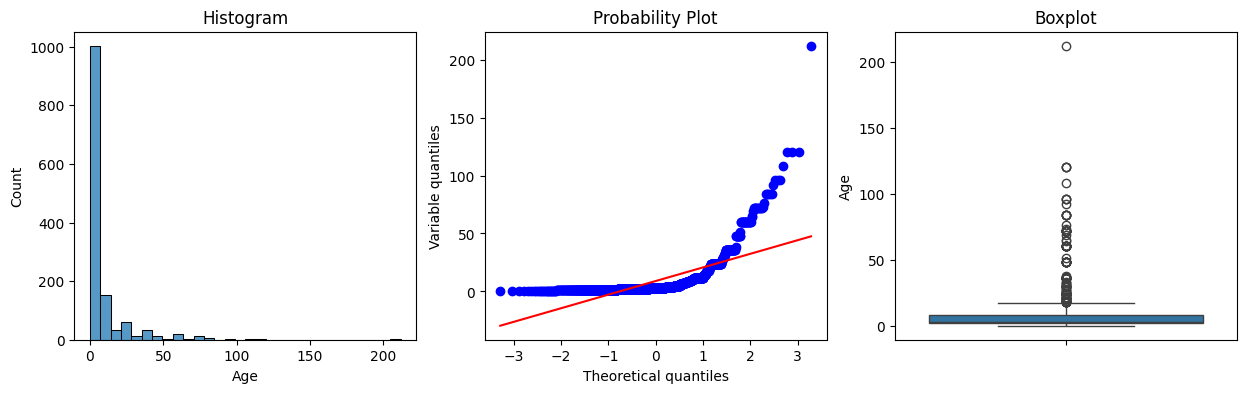

In [342]:
diagnostic_plots(ds, 'Age')

**- Гістограма:** Більшість тварин мають вік менше 50 місяців, але є декілька значень, що виходять за рамки цього діапазону, зокрема тварини з віком понад 200 місяців.

**- Q-Q графік:** Точки не слідують діагоналі, що вказує на відхилення від нормального розподілу, особливо для великих значень. Це підкреслює наявність аномалій на вищих квантилях.

**- Ящик з вусами (Boxplot):** На графіку ящика з вусами помітні численні точки, що лежать за межами верхнього "вуса", що також вказує на аномалії в даних.

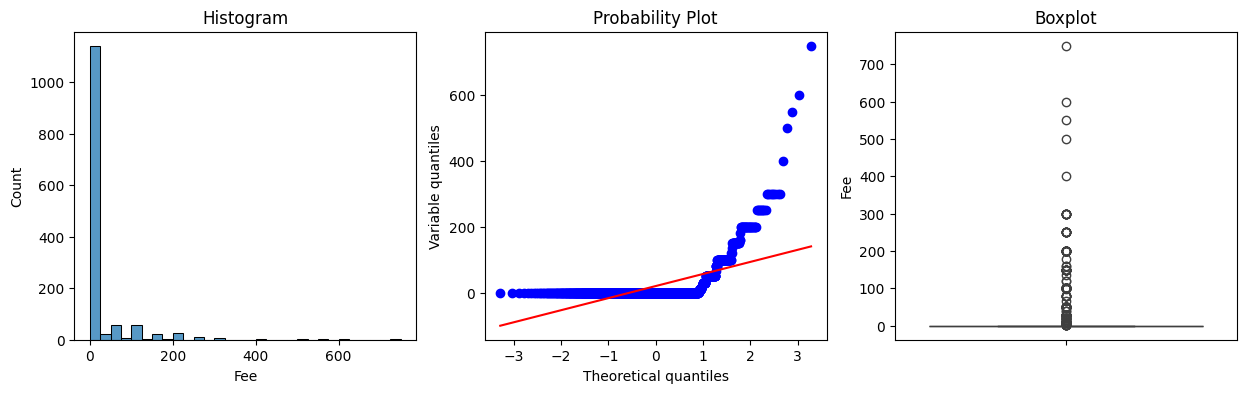

In [343]:
diagnostic_plots(ds, 'Fee')

З аналізу колонки Fee видно, що велика частина значень зосереджена дуже близько до нуля, що робить цей розподіл сильно скошеним (сківдним). Від цього визначення стандартних меж для IQR може бути складним чи навіть неінформативним, як видно на боксплоті, де майже всі дані знаходяться в одному невеликому діапазоні, окрім декількох викидів.

*Аналізуючи змінну Fee за допомогою визначених візуалізацій, можна висновувати наступне:*

**1. Гістограма:**

- Більшість спостережень мають низьку або жодну плату за усиновлення, але є кілька значень, які виходять за рамки звичайних, особливо видно велику кількість тварин з платою 0.
- Помітні декілька випадків із значно вищою платою, що виділяються як потенційні аномалії.

**2. Q-Q графік:**

- Більшість даних не слідують лінії нормального розподілу, що вказує на значне відхилення.
- Видно, що для вищих теоретичних квантилів спостерігається відхилення від норми, що підтверджує наявність аномалій у високих значеннях плати.

**3. Boxplot:**

- На ящику з вусами відзначено значну кількість аномальних значень (показані точками над вусами), які значно вищі за середні показники.

In [377]:
def find_skewed_boundaries(df, variable, distance):
    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)
    
    lower_boundary = df[variable].quantile(0.25) - (IQR * distance)
    upper_boundary = df[variable].quantile(0.75) + (IQR * distance)
    
    return upper_boundary, lower_boundary

In [351]:
Age_upper_limit, Age_lower_limit = find_skewed_boundaries(ds, 'Age', 4)
Age_upper_limit, Age_lower_limit

(32.0, -22.0)

In [354]:
outliers_Age = np.where(ds['Age'] > Age_upper_limit, True,
                       np.where(ds['Age'] < Age_lower_limit, True, False))

In [356]:
ds_trimmed = ds.loc[~outliers_Age, ]

ds.shape, ds_trimmed.shape

((1356, 38), (1260, 38))

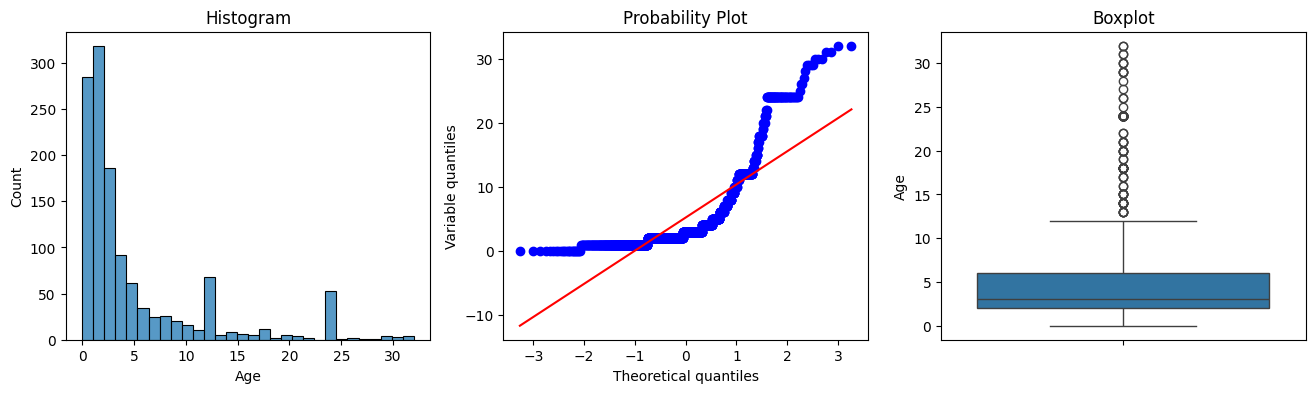

In [358]:
diagnostic_plots(ds_trimmed, 'Age')

In [376]:
# Обчислення статистичних показників до та після обробки аномалій для 'Age'
age_stats_before_after = {
    'before': {'mean': ds['Age'].mean(), 'std': ds['Age'].std(), 'var': ds['Age'].var()},
    'after': {'mean': ds_trimmed['Age'].mean(), 'std': ds_trimmed['Age'].std(), 'var': ds_trimmed['Age'].var()}
}
min_age_before = ds['Age'].min()
max_age_before = ds['Age'].max()
min_age_after = ds_trimmed['Age'].min()
max_age_after = ds_trimmed['Age'].max()

age_stats_text = f"""
============ Статистичні показники для 'Age' ============
Середнє до обробки: {age_stats_before_after['before']['mean']:.2f}
Середнє після обробки: {age_stats_before_after['after']['mean']:.2f}

Стандартне відхилення до обробки: {age_stats_before_after['before']['std']:.2f}
Стандартне відхилення після обробки: {age_stats_before_after['after']['std']:.2f}

Дисперсія до обробки: {age_stats_before_after['before']['var']:.2f}
Дисперсія після обробки: {age_stats_before_after['after']['var']:.2f}

Мінімальне значення до обробки: {min_age_before}
Максимальне значення до обробки: {max_age_before}

Мінімальне значення після обробки: {min_age_after}
Максимальне значення після обробки: {max_age_after}
=========================================================
"""

print(age_stats_text)


============ Статистичні показники для 'Age' ============
Середнє до обробки: 8.96
Середнє після обробки: 5.21

Стандартне відхилення до обробки: 16.46
Стандартне відхилення після обробки: 6.24

Дисперсія до обробки: 270.81
Дисперсія після обробки: 38.95

Мінімальне значення до обробки: 0
Максимальне значення до обробки: 212

Мінімальне значення після обробки: 0
Максимальне значення після обробки: 32



## Масштабування значень ознак

In [383]:
ds_trimmed.describe()

,Type,Age,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,VideoAmt,PhotoAmt,AdoptionSpeed,BreedName_x,BreedName_y,StateName_x,MaturitySize_ModeImputed,MaturitySize_RandomImputed,Gender_RandomImputed,Gender_NA,MaturitySize_NA,ColorName_NA,ColorName_x_Golden,ColorName_x_Cream,ColorName_x_Brown,ColorName_x_Yellow,ColorName_y_Yellow,ColorName_y_Gray,ColorName_y_Cream,ColorName_y_Golden,ColorName_Golden,ColorName_White,ColorName_Yellow,ColorName_Gray
count,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000
mean,1.573810,5.206349,1.570635,1.791270,1.580159,1.974603,1.023016,2.311111,19.296032,41345.146032,0.076984,4.765873,2.446825,12.333333,13.051587,0.824603,1.869841,1.863492,2.129365,0.047619,0.100794,0.152381,0.049206,0.017460,0.164286,0.035714,0.136508,0.166667,0.146032,0.104762,0.045238,0.721429,0.040476,0.083333
std,0.494719,6.241267,0.621762,0.601893,0.659087,0.525133,0.160253,2.031922,58.797633,31.989637,0.466113,4.042854,1.209388,17.036708,22.163227,1.589340,0.501510,0.521591,0.747733,0.213043,0.301175,0.359532,0.216384,0.131031,0.370682,0.185651,0.343463,0.372826,0.353278,0.306368,0.207908,0.448474,0.197152,0.276495
min,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,41324.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,0.000000,41326.000000,0.000000,2.000000,1.000000,2.000000,2.000000,0.000000,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,3.000000,1.500000,2.000000,1.000000,2.000000,1.000000,1.000000,0.000000,41326.000000,0.000000,4.000000,2.000000,3.000000,3.000000,0.000000,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,2.000000,6.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,0.000000,41336.000000,0.000000,5.250000,4.000000,15.000000,15.000000,1.000000,2.000000,2.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,2.000000,32.000000,3.000000,3.000000,3.000000,3.000000,3.000000,20.000000,750.000000,41401.000000,8.000000,30.000000,4.000000,94.000000,122.000000,11.000000,3.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Scaling to Minimum and Maximum values - MinMaxScaling

Метод `Min-Max Scaling` був вибраний для наступних ознак: `Age`, `Quantity`, `Fee`, `PhotoAmt`. Ось чому:

- **Різноманітність масштабів**: Ознаки мають різні масштаби; наприклад, `Fee` варіюється від 0 до 750, а `Age` — від 0 до 32.

- **Нормалізація до [0,1]**: Метод `Min-Max Scaling` нормалізує кожну ознаку до діапазону [0,1], що робить дані сумісними для алгоритмів, які чутливі до масштабу ознак. Цей метод також є корисним, коли діапазони даних відомі, як це є з данними про вік та фотографії.

- **Збереження розподілів**: Після масштабування, основні характеристики розподілів (наприклад, форма розподілу) зазвичай зберігаються, що важливо для інтерпретації моделей і результатів.

Використання `Min-Max Scaling` дозволяє забезпечити, що ознаки мають однаковий масштаб, що полегшує процес навчання і покращує ефективність алгоритмів машинного навчання.

In [395]:
from sklearn.preprocessing import MinMaxScaler

In [400]:
scaler = MinMaxScaler()

scaler.fit(ds_trimmed[['Age','Quantity', 'Fee', 'PhotoAmt']])

X_train_scaled = scaler.transform(ds_trimmed[['Age','Quantity', 'Fee', 'PhotoAmt']])

In [401]:
scaler.data_max_

array([ 32.,  20., 750.,  30.])

In [402]:
scaler.min_

array([ 0.        , -0.05263158,  0.        ,  0.        ])

In [403]:
scaler.data_range_

array([ 32.,  19., 750.,  30.])

In [404]:
X_train = ds_trimmed[['Age','Quantity', 'Fee', 'PhotoAmt']]
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

In [405]:
np.round(X_train_scaled.describe(), 1)

,Age,Quantity,Fee,PhotoAmt
count,1260.0,1260.0,1260.0,1260.0
mean,0.2,0.1,0.0,0.2
std,0.2,0.1,0.1,0.1
min,0.0,0.0,0.0,0.0
25%,0.1,0.0,0.0,0.1
50%,0.1,0.0,0.0,0.1
75%,0.2,0.1,0.0,0.2
max,1.0,1.0,1.0,1.0


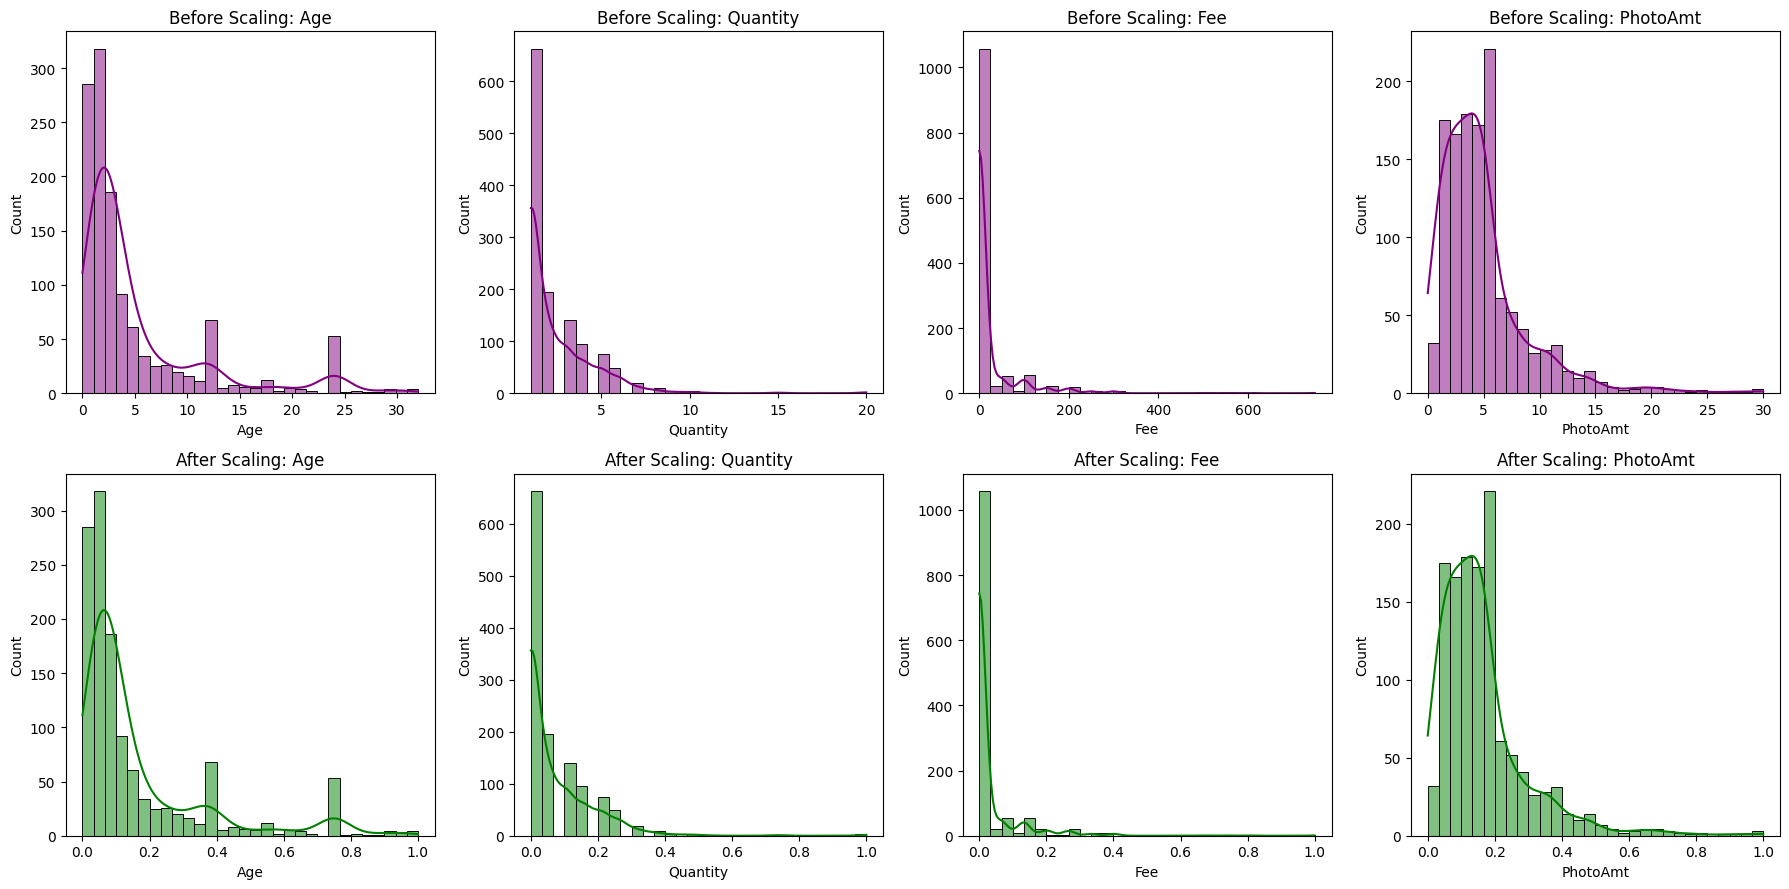

In [415]:
original_data = ds_trimmed[['Age', 'Quantity', 'Fee', 'PhotoAmt']].copy()

X_train_scaled_data = pd.DataFrame(X_train_scaled, columns=['Age', 'Quantity', 'Fee', 'PhotoAmt'])
def plot_histograms(original, scaled, features):
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))

    for i, feature in enumerate(features):
        sns.histplot(original[feature], bins=30, ax=axes[0, i], color='purple', kde=True)
        axes[0, i].set_title(f'Before Scaling: {feature}')

        sns.histplot(scaled[feature], bins=30, ax=axes[1, i], color='green', kde=True)
        axes[1, i].set_title(f'After Scaling: {feature}')

    plt.tight_layout()
    plt.show()

features = ['Age', 'Quantity', 'Fee', 'PhotoAmt']
plot_histograms(original_data, X_train_scaled_data, features)

## Висновок

*У ході виконання практичної роботи я зосередився на підготовці даних для моделювання ймовірності усиновлення тварин у притулку. Основним завданням було вирішення проблем якості даних, таких як пропущені значення, аномалії та некоректне кодування категоріальних ознак. Спочатку я проаналізував наявність відсутніх значень у ключових стовпцях, таких як Gender, MaturitySize та інші й застосував методи імпутації, зокрема заповнення найбільш частими значеннями та випадкову імпутацію. Це дозволило зберегти статистичні властивості даних та уникнути суттєвого спотворення розподілу.*

*Далі я виконав кодування категоріальних змінних, таких як StateName_x, за допомогою Integer Encoding і One-Hot Encoding, що забезпечило коректне представлення цих ознак для подальшого машинного навчання. Для обробки аномальних значень у стовпці Age було визначено верхні та нижні межі допустимих значень, після чого дані були очищені від значних відхилень.*

*На завершення, я провів масштабування числових ознак, таких як Age, Quantity, Fee, і PhotoAmt, щоб зберегти єдиний масштаб для всіх змінних. Це допомогло уникнути домінування окремих ознак у моделі та поліпшило її ефективність. Завдяки цим крокам я створив чистий і готовий до моделювання набір даних, що значно підвищує якість прогнозів і сприяє досягненню мети проекту — підвищення шансів тварин на усиновлення.*